In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA 
from sklearn.metrics import classification_report,  precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt


In [48]:
df = pd.read_csv('heart.csv')

print(df.head())
# Perform data preprocessing & EDA (missing values, scaling, encoding, correlations).
df.info()
df.describe()
df.isnull().sum()   


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [49]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [50]:
Rf_transfrormer = ColumnTransformer(transformers=[
    ('num', StandardScaler(), ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']),
    ('cat', OneHotEncoder(), ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'])
])
pipeline = Pipeline(steps=[
    ('preprocessor', Rf_transfrormer),   
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("classification_report",classification_report(y_test, y_pred))
print("pipeline.score",pipeline.score(X_test, y_test))
print("Accuracy:", (y_test == y_pred).mean())
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))  
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))



classification_report               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

pipeline.score 0.9853658536585366
Accuracy: 0.9853658536585366
Precision: 1.0
Recall: 0.970873786407767
F1-score: 0.9852216748768473
ROC-AUC: 0.9854368932038835


Cluster
2    274
0    263
3    262
1    226
Name: count, dtype: int64
Silhouette Score: 0.10661660841003273


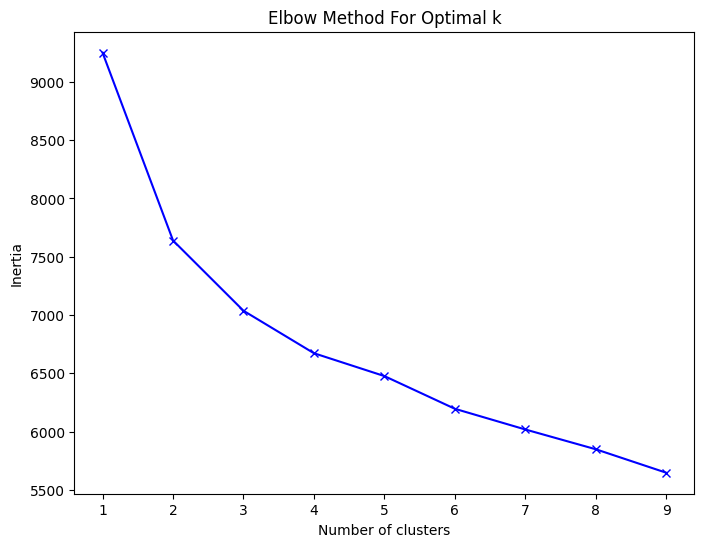

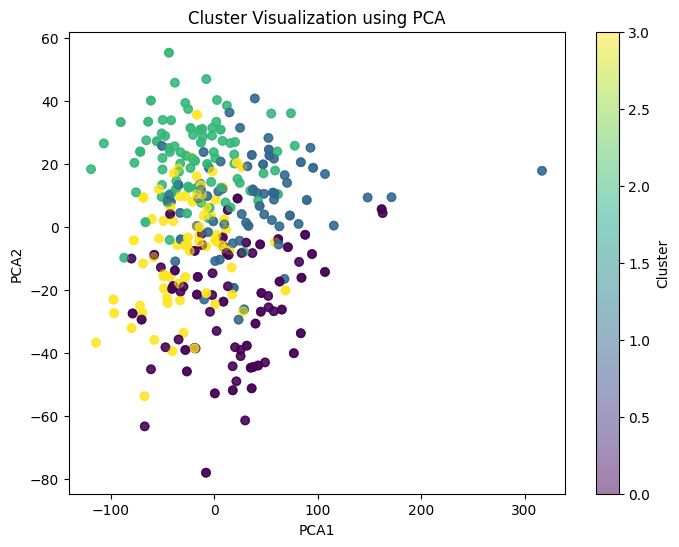

In [51]:
Kmeans_transformer = ColumnTransformer(transformers=[
    ('num', StandardScaler(), ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']),
    ('cat', OneHotEncoder(), ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'])  
])

kmeans_pipeline = Pipeline(steps=[
    ('preprocessor', Kmeans_transformer),
    ("pca", PCA(n_components=2)),
    ('kmeans', KMeans(n_clusters=4, random_state=42))
])
kmeans_pipeline.fit(X)
clusters = kmeans_pipeline.named_steps['kmeans'].labels_
df['Cluster'] = clusters
print(df['Cluster'].value_counts())
  

from sklearn.metrics import silhouette_score    
X_transformed = kmeans_pipeline.named_steps['preprocessor'].transform(X)
sil_score = silhouette_score(X_transformed, clusters)
print("Silhouette Score:", sil_score)

inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_transformed)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]


plt.figure(figsize=(8, 6))
plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster'], cmap='viridis', alpha=0.5)
plt.title('Cluster Visualization using PCA')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.colorbar(label='Cluster')
plt.show()


In [ ]:
# Supervised insights from Random Forest
feature_importances = pipeline.named_steps['classifier'].feature_importances_
feature_names = (pipeline.named_steps['preprocessor']
                 .transformers_[0][2] + 
                 list(pipeline.named_steps['preprocessor']
                      .transformers_[1][1]
                      .get_feature_names_out(pipeline.named_steps['preprocessor']
                                             .transformers_[1][2])))
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print("Feature Importances from Random Forest:")
print(importance_df)



Feature Importances from Random Forest:
      Feature  Importance
7        cp_0    0.098913
4     oldpeak    0.095042
3     thalach    0.092834
21       ca_0    0.083042
28     thal_2    0.082802
29     thal_3    0.075372
2        chol    0.069331
0         age    0.067210
1    trestbps    0.057468
17    exang_1    0.032748
16    exang_0    0.027369
20    slope_2    0.026494
19    slope_1    0.021599
5       sex_0    0.018337
23       ca_2    0.017511
22       ca_1    0.017440
6       sex_1    0.016146
9        cp_2    0.014358
14  restecg_1    0.013624
8        cp_1    0.011903
13  restecg_0    0.011597
10       cp_3    0.011213
24       ca_3    0.010638
11      fbs_0    0.007511
12      fbs_1    0.006529
27     thal_1    0.005351
18    slope_0    0.004448
25       ca_4    0.001775
15  restecg_2    0.000843
26     thal_0    0.000552


In [53]:
# Unsupervised insights from KMeans
cluster_centers = kmeans_pipeline.named_steps['kmeans'].cluster_centers_
print("Cluster Centers from KMeans:")
print(cluster_centers)

Cluster Centers from KMeans:
[[-1.93234171 -0.14686705]
 [ 0.08096318  1.34082255]
 [ 1.81437615 -0.1090633 ]
 [-0.02759876 -0.89510121]]


In [54]:

key_features = importance_df.head(10)
print("Key Features Affecting Heart Disease:")
print(key_features)

print()

print("Best-performing Classification Results:")
print("Random Forest Classifier:")
print("Accuracy:", pipeline.score(X_test, y_test))
print("F1 Score:", f1_score(y_test, pipeline.predict(X_test)))


print()
print("Meaningful Clusters & Their Healthcare Implications:")
for i, center in enumerate(cluster_centers):
    print(f"Cluster {i}:")
    print(center)

Key Features Affecting Heart Disease:
     Feature  Importance
7       cp_0    0.098913
4    oldpeak    0.095042
3    thalach    0.092834
21      ca_0    0.083042
28    thal_2    0.082802
29    thal_3    0.075372
2       chol    0.069331
0        age    0.067210
1   trestbps    0.057468
17   exang_1    0.032748

Best-performing Classification Results:
Random Forest Classifier:
Accuracy: 0.9853658536585366
F1 Score: 0.9852216748768473

Meaningful Clusters & Their Healthcare Implications:
Cluster 0:
[-1.93234171 -0.14686705]
Cluster 1:
[0.08096318 1.34082255]
Cluster 2:
[ 1.81437615 -0.1090633 ]
Cluster 3:
[-0.02759876 -0.89510121]
